In [3]:
import pandas as pd

In [4]:
df=pd.read_csv(r"C:\Users\ARPIT\Desktop\Sales and Business Analytics Project\Sample - Superstore.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,03-01-2020,07-01-2020,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2020-112326,04-01-2020,08-01-2020,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2020-112326,04-01-2020,08-01-2020,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2020-112326,04-01-2020,08-01-2020,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2020-141817,05-01-2020,12-01-2020,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [7]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [11]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [12]:
df['Delivery Days'].head()

0    4
1    4
2    4
3    4
4    7
Name: Delivery Days, dtype: int64

In [13]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [14]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

In [15]:
monthly_sales['Month'] = monthly_sales['Month'].astype(str)

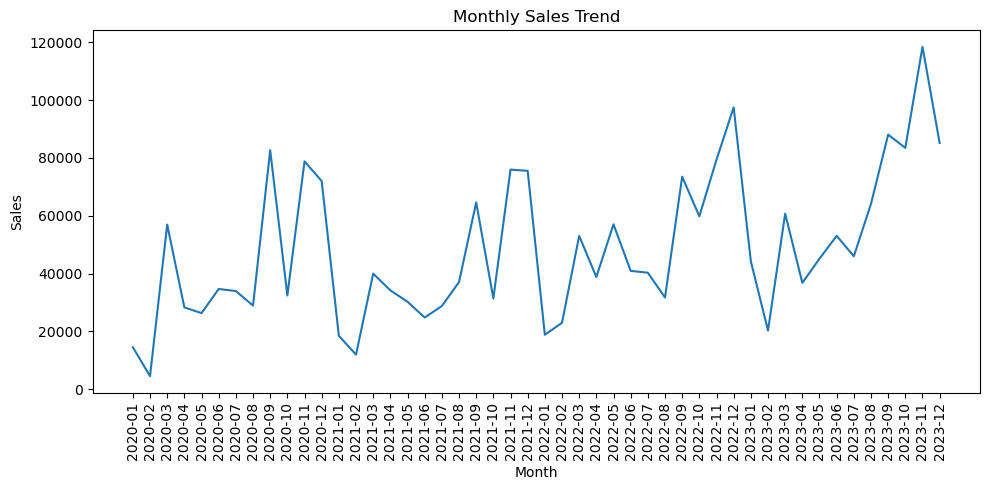

In [16]:
import matplotlib.pyplot as plt

monthly_sales['Month'] = monthly_sales['Month'].astype(str)

plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month'], monthly_sales['Sales'])

plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [32]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()

In [33]:
top_products = top_products.sort_values(by='Sales', ascending=False)

In [34]:
top_10 = top_products.head(10)
print(top_10)

                                          Product Name      Sales
404              Canon imageCLASS 2200 Advanced Copier  61599.824
649  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
785       HON 5400 Series Task Chairs for Big and Tall  21870.576
685         GBC DocuBind TL300 Electric Binding System  19823.479
687   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
804               Hewlett Packard LaserJet 3310 Copier  18839.686
786  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
682          GBC DocuBind P400 Electric Binding System  17965.068
812        High Speed Automatic Electric Letter Opener  17030.312


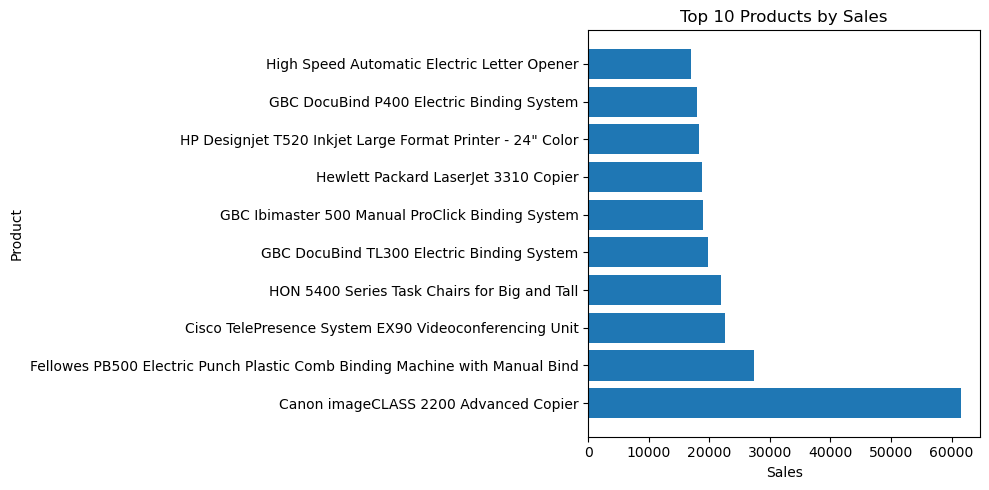

In [35]:

plt.figure(figsize=(10,5))

plt.barh(top_10['Product Name'], top_10['Sales'])

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [17]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
print(category_sales)

          Category        Sales
0        Furniture  754747.7613
1  Office Supplies  731893.3140
2       Technology  839893.2790


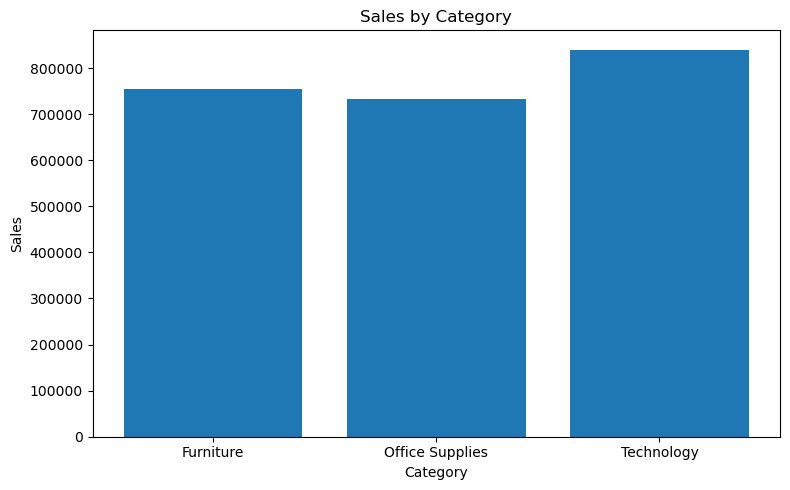

In [18]:
plt.figure(figsize=(8,5))

plt.bar(category_sales['Category'], category_sales['Sales'])

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [19]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()
print(category_profit)

          Category       Profit
0        Furniture   19729.9956
1  Office Supplies  126023.4434
2       Technology  146543.3756


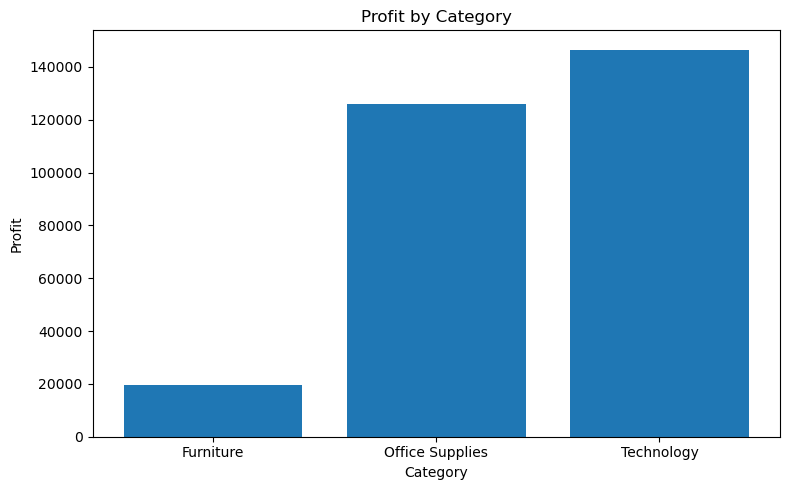

In [20]:
plt.figure(figsize=(8,5))

plt.bar(category_profit['Category'], category_profit['Profit'])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

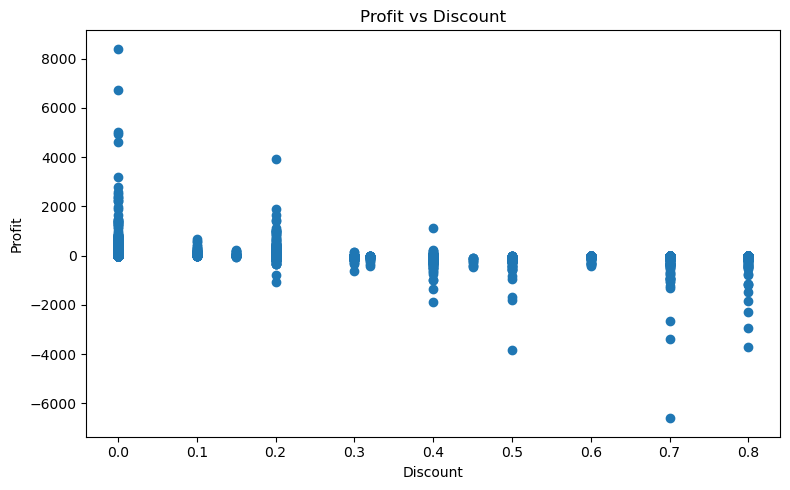

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Profit'])

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [21]:
df.to_csv("cleaned_superstore.csv", index=False)